# Day 2: Plotting & Data Exploration
## Bioinformatics Course - IMBB-FORTH

**Lesson 2** Data visualization and exploration.

### Objectives
By the end of this session, you will:
- Load and explore tabular data with pandas
- Create visualizations with seaborn
- Filter, sort, and group data
- Preview gene expression data

---

## 1. Import Libraries

We'll use three main libraries today:
- **pandas**: For working with data tables
- **seaborn**: For visualization
- **numpy**: For numerical operations

In [7]:
import pandas as pd
import seaborn as sns
import numpy as np

# Set plotting style
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


---

## 2. Loading Data: Cretan Beaches Dataset

This dataset contains environmental and ecological measurements from beaches across Crete.

In [8]:
# Load the dataset
beaches = pd.read_csv('../data/cretan_beaches.csv')

# Display first few rows
beaches.head()

,beach_name,region,compass_direction,longitude,beach_type,beach_length_m,phoenix_palms,juniper_density,lionfish_abundance,cornetfish_abundance,sea_temp_celsius,wind_speed_kmh,annual_rainfall_mm,avg_tourists_per_day
0,Elafonissi,Chania,SW,23.54,sand,1200,45,7,3,5,27.3,22,667,4200
1,Balos,Chania,NW,23.59,sand,500,25,3,2,3,26.4,30,599,3800
2,Falasarna,Chania,NW,23.46,sand,3000,30,6,2,4,23.6,32,623,2100
3,Vai,Lassithi,NE,26.26,sand,200,250,2,7,10,25.8,35,439,2600
4,Preveli,Rethymno,S,24.47,mixed,400,800,4,5,6,24.2,18,528,650


### Understanding the Data Structure

In [9]:
# Dataset shape: (rows, columns)
print("Dataset shape:", beaches.shape)
print(f"We have {beaches.shape[0]} beaches and {beaches.shape[1]} variables")

# Column names
print("\nColumns:")
print(beaches.columns.tolist())

Dataset shape: (27, 14)
We have 27 beaches and 14 variables

Columns:
['beach_name', 'region', 'compass_direction', 'longitude', 'beach_type', 'beach_length_m', 'phoenix_palms', 'juniper_density', 'lionfish_abundance', 'cornetfish_abundance', 'sea_temp_celsius', 'wind_speed_kmh', 'annual_rainfall_mm', 'avg_tourists_per_day']


In [10]:
# Data types for each column
beaches.dtypes

beach_name               object
region                   object
compass_direction        object
longitude               float64
beach_type               object
beach_length_m            int64
phoenix_palms             int64
juniper_density           int64
lionfish_abundance        int64
cornetfish_abundance      int64
sea_temp_celsius        float64
wind_speed_kmh            int64
annual_rainfall_mm        int64
avg_tourists_per_day      int64
dtype: object

In [11]:
# Summary statistics for numerical columns
beaches.describe()

,longitude,beach_length_m,phoenix_palms,juniper_density,lionfish_abundance,cornetfish_abundance,sea_temp_celsius,wind_speed_kmh,annual_rainfall_mm,avg_tourists_per_day
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,24.295185,747.037037,90.481481,3.703704,3.481481,4.555556,24.648148,18.518519,563.222222,1182.962963
std,0.636574,675.510148,153.293427,1.897667,1.718013,2.172084,1.079662,7.282066,57.222463,1139.020547
min,23.460000,100.000000,0.000000,1.000000,1.000000,1.000000,22.800000,8.000000,419.000000,60.000000
25%,24.045000,275.000000,25.000000,2.500000,2.000000,3.000000,23.800000,14.500000,532.000000,385.000000
50%,24.150000,500.000000,40.000000,4.000000,3.000000,4.000000,24.500000,18.000000,566.000000,700.000000
75%,24.580000,1050.000000,92.500000,5.000000,4.000000,5.500000,25.350000,21.000000,598.000000,1750.000000
max,26.260000,3000.000000,800.000000,8.000000,8.000000,10.000000,27.300000,35.000000,667.000000,4200.000000


### 💡 Exercise 2.1: Data Exploration

**Task:**
1. How many different regions are in the dataset?
2. How many different beach types are there?
3. What is the warmest beach temperature recorded?

In [12]:
# Your code here

# Number of unique regions
n_regions = beaches['region'].nunique()
print(f"Number of regions: {n_regions}")

# Unique beach types
beach_types = # Your code
print(f"Beach types: {beach_types}")

# Maximum temperature
max_temp = # Your code
print(f"Maximum temperature: {max_temp}°C")

SyntaxError: invalid syntax (2798533536.py, line 8)

---

## 3. Data Visualization with Seaborn

Seaborn makes it easy to create informative visualizations.

### Scatter Plot: Relationships Between Variables

Notice: Warmer beaches tend to have more tourists


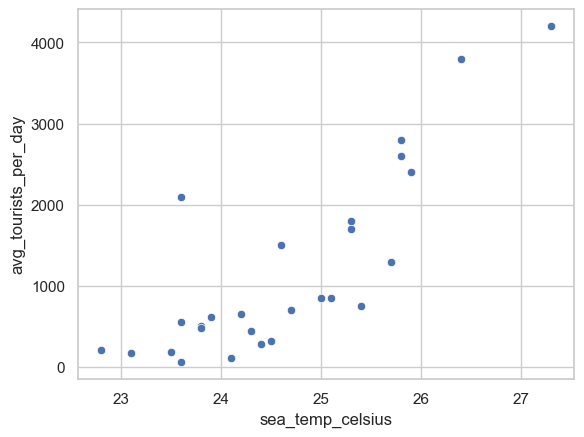

In [13]:
# Temperature vs Tourism
sns.scatterplot(data=beaches, x='sea_temp_celsius', y='avg_tourists_per_day')
print("Notice: Warmer beaches tend to have more tourists")

<Axes: xlabel='sea_temp_celsius', ylabel='avg_tourists_per_day'>

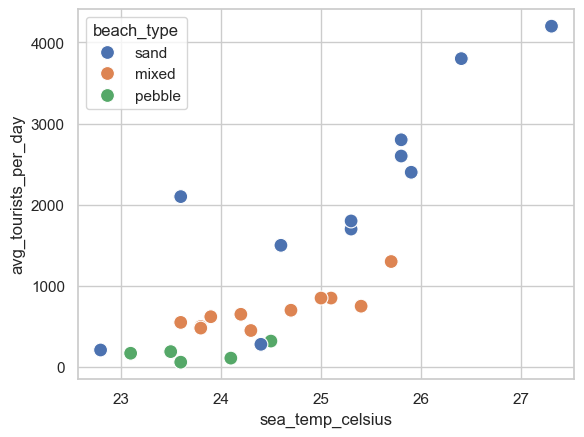

In [14]:
# Add color by beach type
sns.scatterplot(data=beaches, 
                x='sea_temp_celsius', 
                y='avg_tourists_per_day',
                hue='beach_type',
                s=100)  # s = marker size

### Histogram: Distribution of a Single Variable

Most beaches have temperatures between 24-27°C


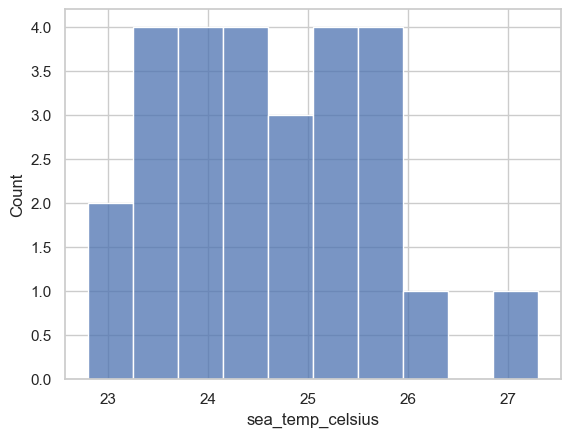

In [15]:
# Distribution of sea temperatures
sns.histplot(data=beaches, x='sea_temp_celsius', bins=10)
print("Most beaches have temperatures between 24-27°C")

<Axes: xlabel='sea_temp_celsius', ylabel='Count'>

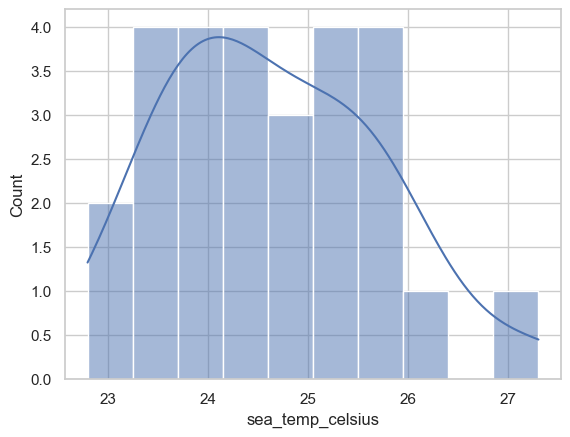

In [16]:
# With density curve
sns.histplot(data=beaches, x='sea_temp_celsius', bins=10, kde=True)

### Box Plot: Comparing Groups

North-facing beaches tend to be warmer


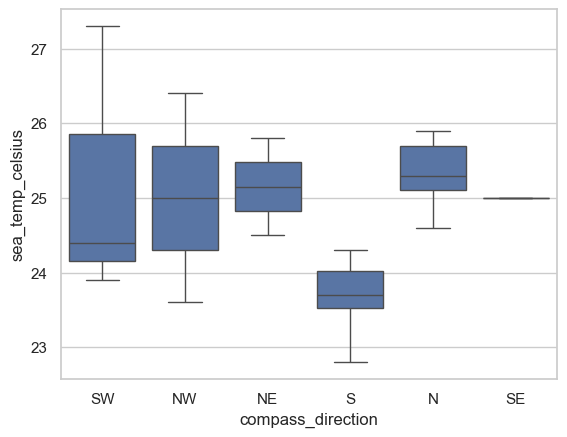

In [17]:
# Temperature by compass direction
sns.boxplot(data=beaches, x='compass_direction', y='sea_temp_celsius')
print("North-facing beaches tend to be warmer")

<Axes: xlabel='beach_type', ylabel='avg_tourists_per_day'>

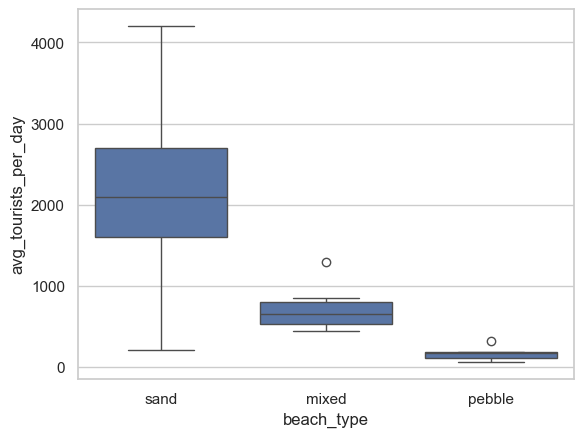

In [18]:
# Tourism by beach type
sns.boxplot(data=beaches, x='beach_type', y='avg_tourists_per_day')

### 💡 Exercise 2.2: Create Your Own Plots

**Task:**
1. Create a scatter plot of `wind_speed_kmh` vs `avg_tourists_per_day`
2. Create a histogram of `annual_rainfall_mm`
3. Create a box plot of `lionfish_abundance` by `compass_direction`

In [19]:
# 1. Wind speed vs tourism
# Your code here


In [20]:
# 2. Rainfall distribution
# Your code here


In [21]:
# 3. Lionfish by direction
# Your code here


---

## 4. Data Operations with Pandas

Pandas allows us to filter, select, and manipulate data efficiently.

### Selecting Columns

In [22]:
# Single column - returns a Series
temperatures = beaches['sea_temp_celsius']
print(type(temperatures))
print(temperatures.head())

<class 'pandas.core.series.Series'>
0    27.3
1    26.4
2    23.6
3    25.8
4    24.2
Name: sea_temp_celsius, dtype: float64


In [23]:
# Multiple columns - returns a DataFrame
subset = beaches[['beach_name', 'sea_temp_celsius', 'avg_tourists_per_day']]
print(type(subset))
subset.head()

<class 'pandas.core.frame.DataFrame'>


,beach_name,sea_temp_celsius,avg_tourists_per_day
0,Elafonissi,27.3,4200
1,Balos,26.4,3800
2,Falasarna,23.6,2100
3,Vai,25.8,2600
4,Preveli,24.2,650


### Selecting Specific Rows and Columns with `.loc[]`

Sometimes you need to select specific rows **and** columns at the same time.
The `.loc[]` accessor lets you do this: `df.loc[rows, columns]`.

We'll use this more in later days when working with expression data.

In [24]:
# Select specific rows by condition AND specific columns
beaches.loc[beaches['beach_type'] == 'sand', ['beach_name', 'sea_temp_celsius']]

,beach_name,sea_temp_celsius
0,Elafonissi,27.3
1,Balos,26.4
2,Falasarna,23.6
3,Vai,25.8
8,Georgioupoli,25.9
9,Stavros,25.3
12,Panormos,24.6
13,Almyrida,25.3
17,Kedrodasos,24.4
24,Chania Beach,25.8


### Filtering Rows: Boolean Indexing

In [25]:
# Find beaches warmer than 25°C
warm_beaches = beaches[beaches['sea_temp_celsius'] > 25]
print(f"Found {len(warm_beaches)} warm beaches")
warm_beaches[['beach_name', 'sea_temp_celsius', 'compass_direction']]

Found 10 warm beaches


,beach_name,sea_temp_celsius,compass_direction
0,Elafonissi,27.3,SW
1,Balos,26.4,NW
3,Vai,25.8,NE
8,Georgioupoli,25.9,N
9,Stavros,25.3,N
10,Agia Pelagia,25.7,N
11,Bali,25.1,N
13,Almyrida,25.3,N
14,Marathi,25.4,N
24,Chania Beach,25.8,N


In [26]:
# Multiple conditions: AND (&)
warm_sandy = beaches[(beaches['sea_temp_celsius'] > 25) & 
                     (beaches['beach_type'] == 'sand')]
print(f"Warm sandy beaches: {len(warm_sandy)}")
warm_sandy[['beach_name', 'sea_temp_celsius']]

Warm sandy beaches: 7


,beach_name,sea_temp_celsius
0,Elafonissi,27.3
1,Balos,26.4
3,Vai,25.8
8,Georgioupoli,25.9
9,Stavros,25.3
13,Almyrida,25.3
24,Chania Beach,25.8


In [27]:
# Multiple conditions: OR (|)
extreme_beaches = beaches[(beaches['sea_temp_celsius'] > 26) | 
                         (beaches['sea_temp_celsius'] < 23)]
print(f"Extreme temperature beaches: {len(extreme_beaches)}")

Extreme temperature beaches: 3


### Sorting Data

In [28]:
# Sort by temperature (ascending)
sorted_temp = beaches.sort_values('sea_temp_celsius')
sorted_temp[['beach_name', 'sea_temp_celsius']].head()

,beach_name,sea_temp_celsius
26,Sarakiniko,22.8
23,Loutro,23.1
22,Sougia,23.5
2,Falasarna,23.6
19,Marmara,23.6


In [29]:
# Sort by temperature (descending)
hottest = beaches.sort_values('sea_temp_celsius', ascending=False)
print("Top 5 warmest beaches:")
hottest[['beach_name', 'sea_temp_celsius']].head()

Top 5 warmest beaches:


,beach_name,sea_temp_celsius
0,Elafonissi,27.3
1,Balos,26.4
8,Georgioupoli,25.9
24,Chania Beach,25.8
3,Vai,25.8


### 💡 Exercise 2.3: Filtering and Sorting

**Task:**
1. Find all beaches with lionfish abundance > 5
2. Find beaches that are both 'sand' type AND have >2000 tourists per day
3. Sort beaches by rainfall (descending) and show the top 3

In [30]:
# 1. High lionfish beaches
# Your code here


In [31]:
# 2. Popular sandy beaches
# Your code here


In [32]:
# 3. Wettest beaches
# Your code here


---

## 5. Groupby: Aggregating Data

The `groupby()` function lets us split data into groups and calculate statistics for each group.

### Basic Groupby

In [33]:
# Average temperature by beach type
beaches.groupby('beach_type')['sea_temp_celsius'].mean()

beach_type
mixed     24.50
pebble    23.76
sand      25.20
Name: sea_temp_celsius, dtype: float64

In [34]:
# Multiple statistics at once
beaches.groupby('beach_type')['sea_temp_celsius'].agg(['mean', 'min', 'max', 'count'])

,mean,min,max,count
beach_type,,,,
mixed,24.50,23.6,25.7,11
pebble,23.76,23.1,24.5,5
sand,25.20,22.8,27.3,11


### Groupby with Multiple Columns

In [35]:
# Average tourism by region
tourism_by_region = beaches.groupby('region')['avg_tourists_per_day'].mean().sort_values(ascending=False)
print("Average tourists by region:")
tourism_by_region

Average tourists by region:


region
Lassithi     1725.000000
Chania       1322.352941
Heraklion     925.000000
Rethymno      790.000000
Gavdos        210.000000
Name: avg_tourists_per_day, dtype: float64

In [36]:
# Compare multiple variables by beach type
beaches.groupby('beach_type')[['sea_temp_celsius', 'avg_tourists_per_day', 'wind_speed_kmh']].mean()

,sea_temp_celsius,avg_tourists_per_day,wind_speed_kmh
beach_type,,,
mixed,24.50,700.000000,17.545455
pebble,23.76,170.000000,11.800000
sand,25.20,2126.363636,22.545455


### Visualizing Grouped Data

<Axes: xlabel='beach_type'>

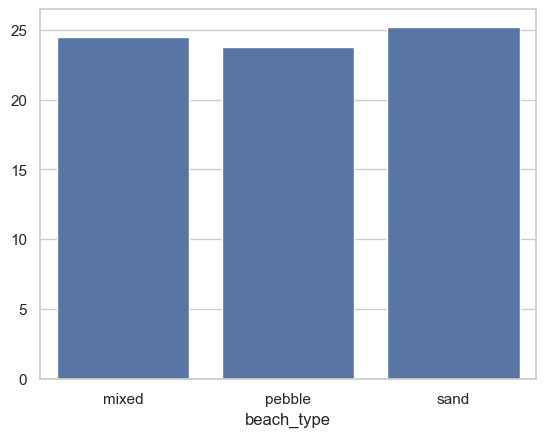

In [37]:
# Bar plot of average temperature by beach type
temp_by_type = beaches.groupby('beach_type')['sea_temp_celsius'].mean()
sns.barplot(x=temp_by_type.index, y=temp_by_type.values)

<Axes: xlabel='beach_type', ylabel='count'>

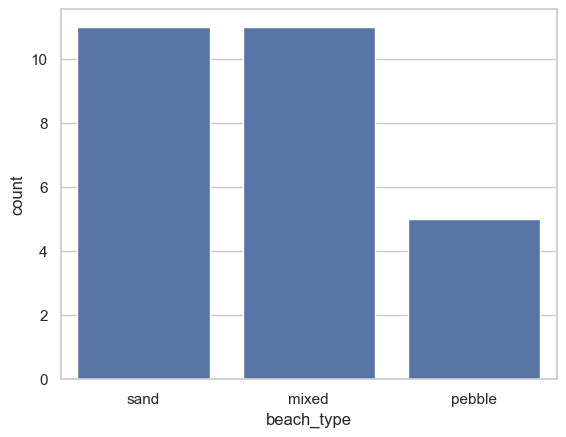

In [38]:
# Count plot - how many beaches of each type?
sns.countplot(data=beaches, x='beach_type')

### 💡 Exercise 2.4: Groupby Operations

**Task:**
1. Calculate mean lionfish abundance by compass direction
2. Find the beach with maximum rainfall in each region
3. Create a bar plot showing average wind speed by compass direction

In [39]:
# 1. Lionfish by direction
# Your code here


In [40]:
# 2. Max rainfall per region
# Your code here


In [41]:
# 3. Wind speed by direction (bar plot)
# Your code here


---

## 6. Preview: Expression Data

Let's briefly look at gene expression data — we'll analyze this more in Days 4-5.
This is a good chance to practice what we just learned on a different dataset.

### Load Expression Data

In [42]:
# Load RNA-seq count data
expression = pd.read_csv('../data/bulk_rnaseq_counts.csv', index_col=0)
metadata = pd.read_csv('../data/bulk_rnaseq_metadata.csv')

print(f"Expression data: {expression.shape[0]} samples × {expression.shape[1]} genes")
print(f"\nConditions: {list(metadata['condition'].unique())}")

expression.head()

Expression data: 9 samples × 100 genes

Conditions: ['Normal', 'Treatment_A', 'Treatment_B']


,Gene_001,Gene_002,Gene_003,Gene_004,Gene_005,Gene_006,Gene_007,Gene_008,Gene_009,Gene_010,...,Gene_091,Gene_092,Gene_093,Gene_094,Gene_095,Gene_096,Gene_097,Gene_098,Gene_099,Gene_100
sample,,,,,,,,,,,,,,,,,,,,,
Normal_Rep1,147,199,164,139,335,252,120,134,113,135,...,153,145,172,140,175,187,144,295,138,224
Normal_Rep2,143,256,221,139,254,275,151,170,111,137,...,169,153,153,154,127,223,133,237,140,201
Normal_Rep3,92,223,186,109,241,295,141,176,84,149,...,185,214,154,191,159,195,92,325,153,257
Treatment_A_Rep1,628,591,998,669,1666,1206,551,394,453,543,...,143,150,197,194,138,219,143,294,146,170
Treatment_A_Rep2,657,1234,709,614,1494,842,506,510,396,555,...,173,140,194,167,136,207,148,211,146,196


In [43]:
# Sample metadata
metadata

,sample_name,condition,replicate
0,Normal_Rep1,Normal,Rep1
1,Normal_Rep2,Normal,Rep2
2,Normal_Rep3,Normal,Rep3
3,Treatment_A_Rep1,Treatment_A,Rep1
4,Treatment_A_Rep2,Treatment_A,Rep2
5,Treatment_A_Rep3,Treatment_A,Rep3
6,Treatment_B_Rep1,Treatment_B,Rep1
7,Treatment_B_Rep2,Treatment_B,Rep2
8,Treatment_B_Rep3,Treatment_B,Rep3


### Visualize a Single Gene Across Samples

Expression of Gene_001 across conditions
Notice how expression differs between conditions


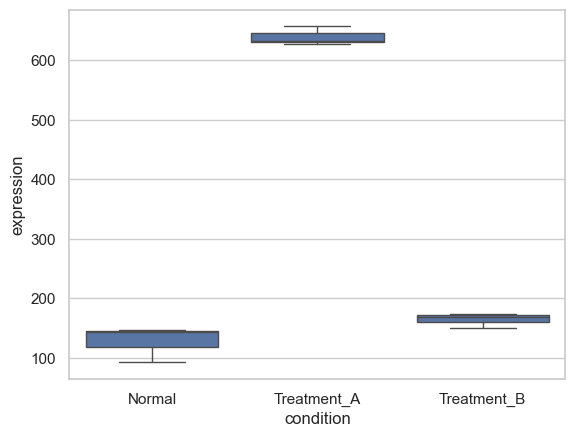

In [44]:
# Pick one gene and visualize its expression across conditions
gene = 'Gene_001'

# Build a DataFrame for plotting
plot_data = pd.DataFrame({
    'sample': expression.index,
    'expression': expression[gene].values,
    'condition': metadata['condition'].values
})

sns.boxplot(data=plot_data, x='condition', y='expression')
print(f"Expression of {gene} across conditions")
print("Notice how expression differs between conditions")

### What We Can See

- Samples from the same condition have **similar expression levels**
- There are clear **differences between conditions** for this gene
- This is what we'll analyze systematically in Days 4-5: which genes differ between conditions?

---

## 🎯 Summary

### Core Concepts
- **Loading data** with `pd.read_csv()`
- **Exploring data** with `.head()`, `.shape`, `.describe()`
- **Seaborn plots** — scatter, histogram, box plot, bar plot
- **Boolean indexing** — filtering rows with conditions
- **Groupby** — aggregating data by categories

### Key Functions
- `pd.read_csv()` — load data
- `sns.scatterplot()`, `sns.histplot()`, `sns.boxplot()`, `sns.barplot()` — visualizations
- `df[df['column'] > value]` — filtering
- `df.groupby('column').mean()` — aggregation

### Tomorrow: Day 3

We'll dive into:
- **P-value logic** — understanding via permutation tests
- **Statistical testing** — t-test, Mann-Whitney U
- **Correlation** — measuring and testing relationships

---

## 💡 Final Exercise: Putting It Together

**Task:** Analyze tourism patterns in Cretan beaches

1. Filter for beaches with >1000 tourists/day
2. Calculate mean temperature for these popular beaches
3. Create a scatter plot of temperature vs tourism for popular beaches only
4. Which beach type has the highest average tourism?

In [45]:
# Your code here

# 1. Filter popular beaches
popular = # Your code

# 2. Mean temperature
mean_temp = # Your code

# 3. Scatter plot
# Your code

# 4. Tourism by beach type
# Your code

SyntaxError: invalid syntax (2006792252.py, line 4)